In [11]:
import json
from pathlib import Path

import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap

# SHAP plots render inline
shap.initjs()

# Use a clean style
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 8)

import warnings
warnings.filterwarnings("ignore")

In [2]:
# Paths (notebook lives in notebooks/, so go up one level)
BASE_DIR = Path.cwd().parent
PROCESSED_DIR = BASE_DIR / "data" / "processed"
MODELS_DIR = BASE_DIR / "models"

# 1. Processed matrices (already scaled + one-hot encoded by feature_engineering.py)
X_test = pd.read_csv(PROCESSED_DIR / "X_test.csv")
y_test = pd.read_csv(PROCESSED_DIR / "y_test.csv").squeeze("columns")

# 2. Exact feature names that the models saw during training
with open(MODELS_DIR / "feature_columns.json", "r") as f:
    feature_columns = json.load(f)

# 3. Trained models dict {name: fitted_model}
all_models = joblib.load(MODELS_DIR / "all_models.pkl")

# 4. Best standalone model + its name
best_model = joblib.load(MODELS_DIR / "best_model.pkl")
with open(MODELS_DIR / "best_model_name.txt", "r") as f:
    best_name = f.read().strip()

# 5. Optional: training comparison table for context
comparison = pd.read_csv(MODELS_DIR / "model_comparison.csv", index_col="model")

print("=" * 60)
print(f"X_test shape:        {X_test.shape}")
print(f"Feature columns:     {len(feature_columns)}")
print(f"Models loaded:       {list(all_models.keys())}")
print(f"Best model:          {best_name}")
print("=" * 60)
print("\nTraining results (from model_comparison.csv):")
display(comparison.round(4))

X_test shape:        (1145, 28)
Feature columns:     28
Models loaded:       ['Linear Regression', 'Random Forest', 'XGBoost']
Best model:          XGBoost

Training results (from model_comparison.csv):


,rmse_log,mae_log,r2_log,rmse_pkr,mae_pkr,r2_pkr
model,,,,,,
Linear Regression,0.1868,0.1155,0.8875,347014.6487,245065.7326,0.9161
Random Forest,0.1582,0.0927,0.9194,292118.6591,191085.2396,0.9405
XGBoost,0.1510,0.0901,0.9265,275116.1081,186630.7325,0.9472


RF expected value (baseline log_price): 14.6460


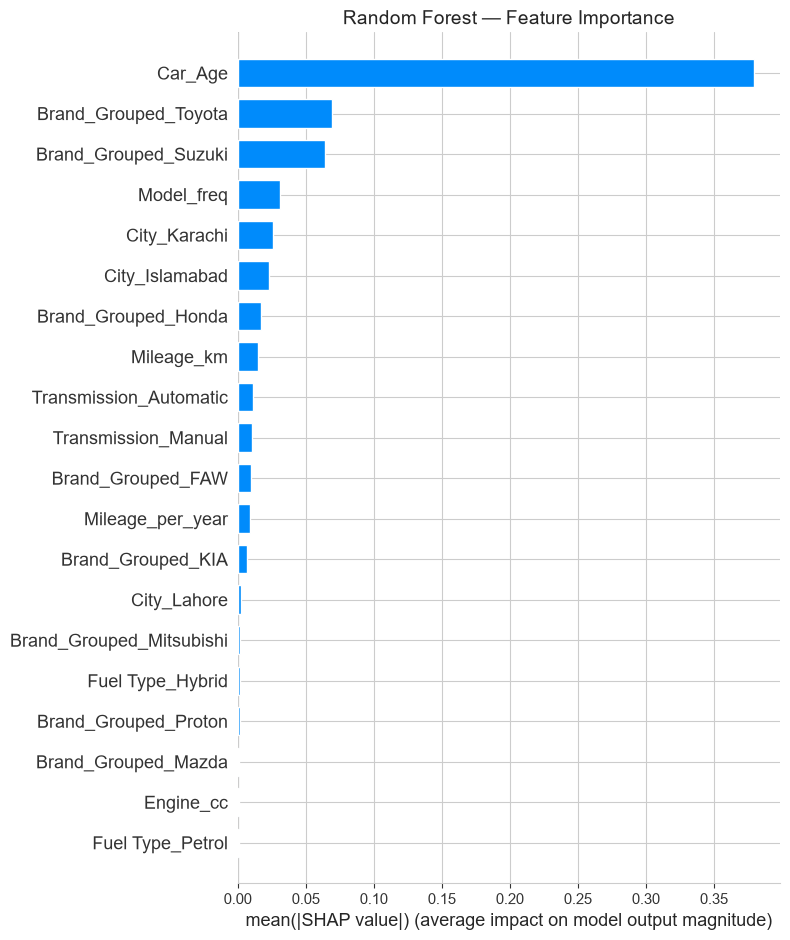

In [13]:
rf_model = all_models["Random Forest"]

rf_explainer = shap.TreeExplainer(rf_model)
rf_shap_values = rf_explainer.shap_values(X_test)

rf_expected = float(rf_explainer.expected_value)
print(f"RF expected value (baseline log_price): {rf_expected:.4f}")

plt.figure(figsize=(10, 8))
shap.summary_plot(rf_shap_values, X_test, plot_type="bar", show=False, max_display=20)
plt.title("Random Forest — Feature Importance", fontsize=14)
plt.tight_layout()
plt.show()

XGB expected value (baseline log_price): 14.6473


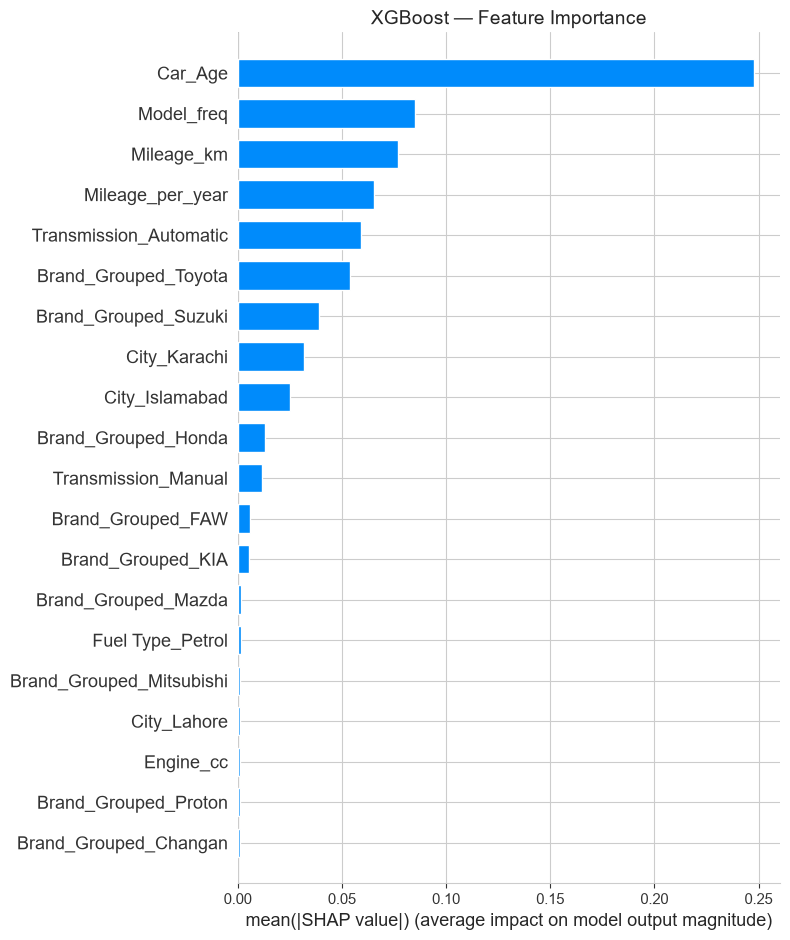

In [14]:
xgb_model = all_models["XGBoost"]

xgb_explainer = shap.TreeExplainer(xgb_model)
xgb_shap_values = xgb_explainer.shap_values(X_test)

xgb_expected = float(xgb_explainer.expected_value)
print(f"XGB expected value (baseline log_price): {xgb_expected:.4f}")

plt.figure(figsize=(10, 8))
shap.summary_plot(xgb_shap_values, X_test, plot_type="bar", show=False, max_display=20)
plt.title("XGBoost — Feature Importance", fontsize=14)
plt.tight_layout()
plt.show()

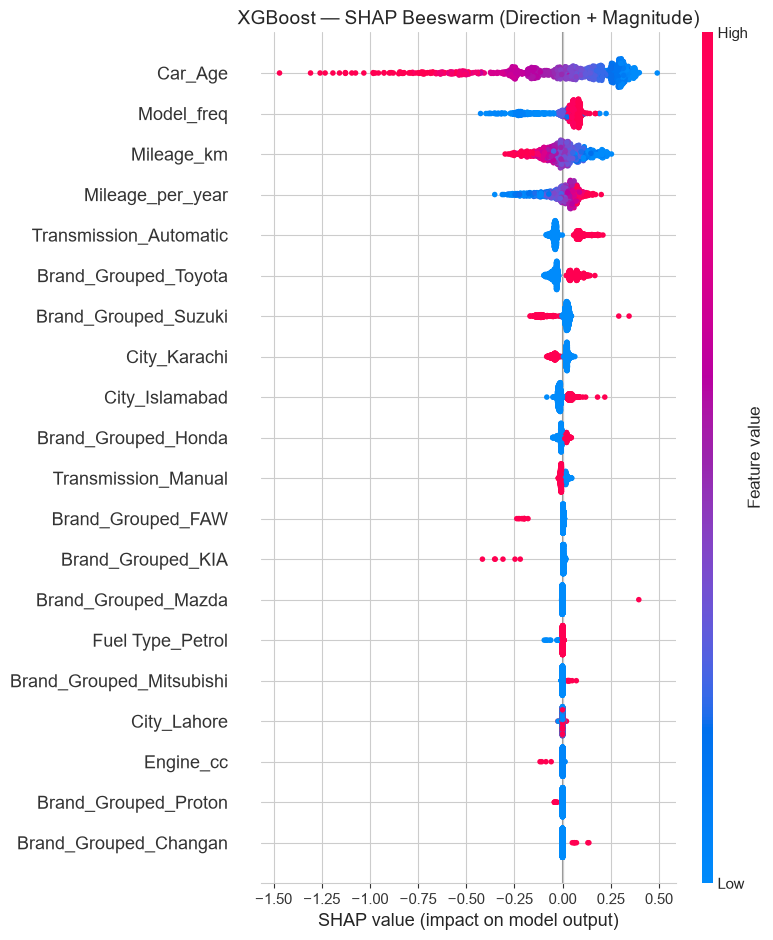

In [15]:
if best_name == "Random Forest":
    best_explainer = rf_explainer
    best_shap_values = rf_shap_values
elif best_name == "XGBoost":
    best_explainer = xgb_explainer
    best_shap_values = xgb_shap_values
else:
    print("If best model is Linear Regression then use KernelExplainer.")
    best_explainer = shap.KernelExplainer(best_model.predict, shap.sample(X_test, 50))
    best_shap_values = best_explainer.shap_values(X_test)

plt.figure(figsize=(10, 8))
shap.summary_plot(best_shap_values, X_test, show=False, max_display=20)
plt.title(f"{best_name} — SHAP Beeswarm (Direction + Magnitude)", fontsize=14)
plt.tight_layout()
plt.show()

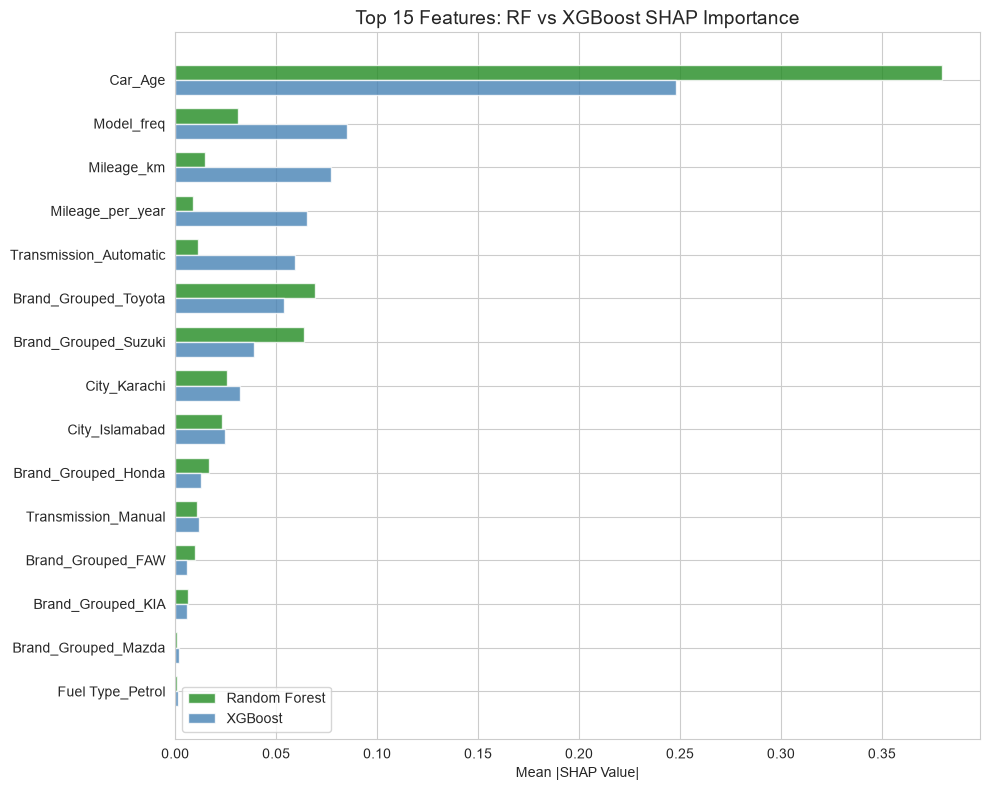


Rank comparison (lower rank = more important):


,Feature,RF_rank,XGB_SHAP,XGB_rank
0,Car_Age,1.0,0.2479,1.0
4,Model_freq,4.0,0.0852,2.0
1,Mileage_km,8.0,0.0771,3.0
3,Mileage_per_year,12.0,0.0654,4.0
13,Transmission_Automatic,9.0,0.0593,5.0
27,Brand_Grouped_Toyota,2.0,0.0541,6.0
26,Brand_Grouped_Suzuki,3.0,0.0391,7.0
6,City_Karachi,5.0,0.0320,8.0
5,City_Islamabad,6.0,0.0249,9.0
18,Brand_Grouped_Honda,7.0,0.0129,10.0


In [7]:
# Mean absolute SHAP per feature
rf_imp = pd.DataFrame({
    "Feature": X_test.columns,
    "RF_SHAP": np.abs(rf_shap_values).mean(axis=0)
})

xgb_imp = pd.DataFrame({
    "Feature": X_test.columns,
    "XGB_SHAP": np.abs(xgb_shap_values).mean(axis=0)
})

# Merge and rank
shap_comp = rf_imp.merge(xgb_imp, on="Feature")
shap_comp["RF_rank"] = shap_comp["RF_SHAP"].rank(ascending=False)
shap_comp["XGB_rank"] = shap_comp["XGB_SHAP"].rank(ascending=False)
shap_comp = shap_comp.sort_values("XGB_SHAP", ascending=False).head(15)

# Plot
fig, ax = plt.subplots(figsize=(10, 8))
y_pos = np.arange(len(shap_comp))
bar_height = 0.35

ax.barh(y_pos - bar_height/2, shap_comp["RF_SHAP"], bar_height, label="Random Forest", color="forestgreen", alpha=0.8)
ax.barh(y_pos + bar_height/2, shap_comp["XGB_SHAP"], bar_height, label="XGBoost", color="steelblue", alpha=0.8)

ax.set_yticks(y_pos)
ax.set_yticklabels(shap_comp["Feature"])
ax.invert_yaxis()
ax.set_xlabel("Mean |SHAP Value|")
ax.set_title("Top 15 Features: RF vs XGBoost SHAP Importance", fontsize=14)
ax.legend()
plt.tight_layout()
plt.show()

print("\nRank comparison (lower rank = more important):")
display(shap_comp[["Feature", "RF_rank", "XGB_SHAP", "XGB_rank"]].round(4))

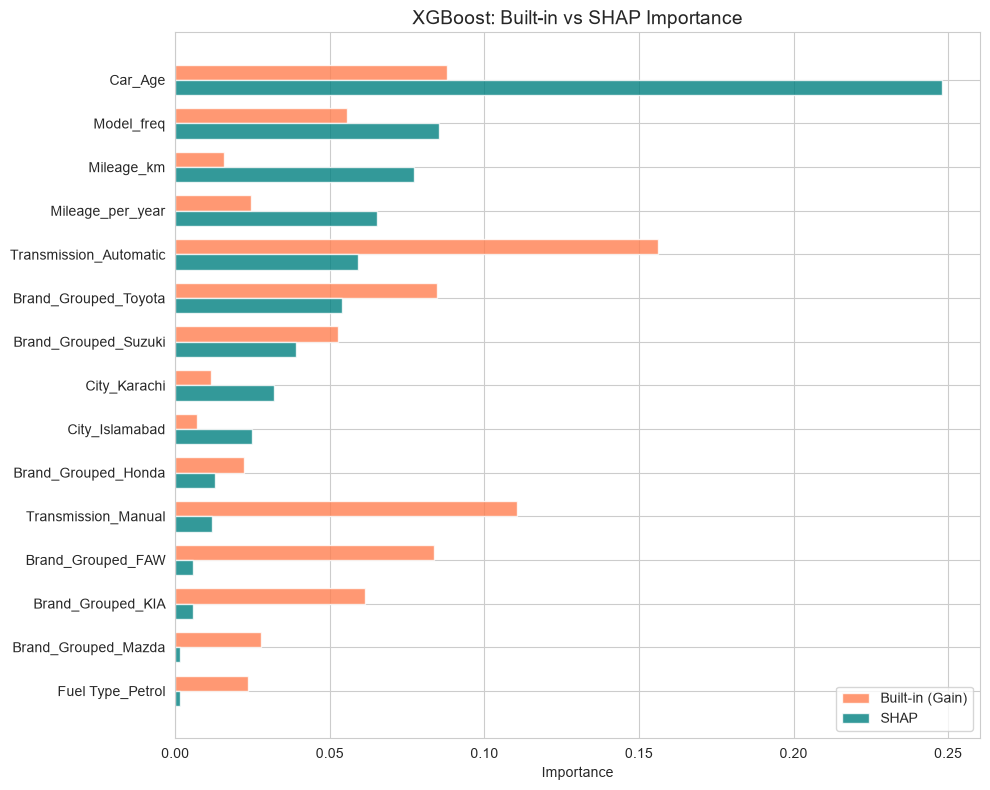

In [8]:
if hasattr(best_model, "feature_importances_"):
    built_in = pd.DataFrame({
        "Feature": X_test.columns,
        "Built_In": best_model.feature_importances_
    })
    
    shap_df = pd.DataFrame({
        "Feature": X_test.columns,
        "SHAP": np.abs(best_shap_values).mean(axis=0)
    })
    
    imp_comp = built_in.merge(shap_df, on="Feature").sort_values("SHAP", ascending=False).head(15)
    
    fig, ax = plt.subplots(figsize=(10, 8))
    y_pos = np.arange(len(imp_comp))
    bar_height = 0.35
    
    ax.barh(y_pos - bar_height/2, imp_comp["Built_In"], bar_height, label="Built-in (Gain)", color="coral", alpha=0.8)
    ax.barh(y_pos + bar_height/2, imp_comp["SHAP"], bar_height, label="SHAP", color="teal", alpha=0.8)
    
    ax.set_yticks(y_pos)
    ax.set_yticklabels(imp_comp["Feature"])
    ax.invert_yaxis()
    ax.set_xlabel("Importance")
    ax.set_title(f"{best_name}: Built-in vs SHAP Importance", fontsize=14)
    ax.legend()
    plt.tight_layout()
    plt.show()
else:
    print("Linear Regression has no built-in tree importance — skipping.")

Top SHAP feature: Car_Age


<Figure size 1000x600 with 0 Axes>

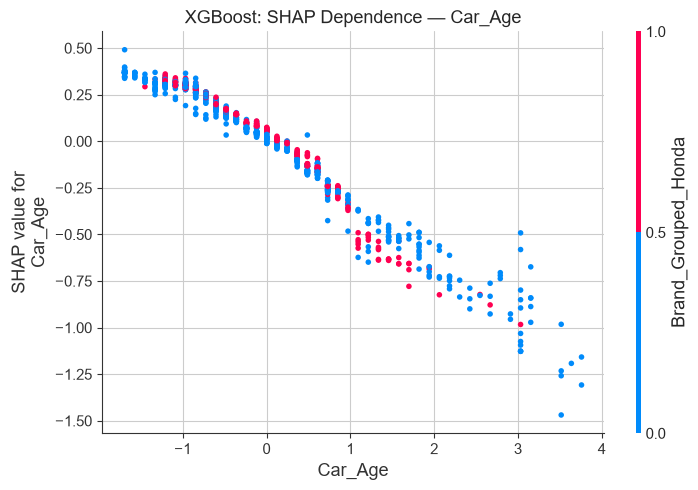

In [9]:
# Identify top feature by SHAP
top_feature = shap_comp.iloc[0]["Feature"]
print(f"Top SHAP feature: {top_feature}")

plt.figure(figsize=(10, 6))
shap.dependence_plot(
    top_feature, 
    best_shap_values, 
    X_test, 
    show=False,
    interaction_index="auto"
)
plt.title(f"{best_name}: SHAP Dependence — {top_feature}", fontsize=13)
plt.tight_layout()
plt.show()